In [1]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [2]:
from torchvision import datasets

train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = train_transform,
    download = True,
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = test_transform,
    download = True,
)

In [3]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), shear=[-10.0, 10.0])
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [4]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [5]:
train_data.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [6]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [7]:
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader(train_data,
                        batch_size=100,
                        shuffle=True,
                        num_workers=1),
    'test': DataLoader(test_data,
                       batch_size=100,
                       shuffle=True,
                       num_workers=1),
}

In [8]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x20228e3ae40>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x20228e3dbd0>}

In [9]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)

        return F.softmax(x)

In [10]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loaders["train"].dataset)} ({100. * batch_idx / len(loaders["train"]):.0f}%)]\t{loss.item():.6f}')


predictions = []
targets = []

def test(final=False):
    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            if final:
                predictions.extend(pred.cpu().numpy())
                targets.extend(target.cpu().numpy())

    test_loss /= len(loaders['test'].dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy {correct}/{len(loaders["test"].dataset)} ({100. * correct / len(loaders["test"].dataset):.0f}%\n)')

In [11]:
epochs = 11

for epoch in range(1, epochs+1):
    train(epoch)
    if epoch == epochs:
        test(True)
    else:
        test()

C:\Users\Alex\AppData\Local\Temp\ipykernel_20200\3936228094.py:24: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Train Epoch: 1 [0/60000 (0%)]	2.300600
Train Epoch: 1 [2000/60000 (3%)]	2.292279
Train Epoch: 1 [4000/60000 (7%)]	2.244889
Train Epoch: 1 [6000/60000 (10%)]	2.152220
Train Epoch: 1 [8000/60000 (13%)]	2.134834
Train Epoch: 1 [10000/60000 (17%)]	2.043245
Train Epoch: 1 [12000/60000 (20%)]	2.060695
Train Epoch: 1 [14000/60000 (23%)]	2.101473
Train Epoch: 1 [16000/60000 (27%)]	1.987971
Train Epoch: 1 [18000/60000 (30%)]	2.031436
Train Epoch: 1 [20000/60000 (33%)]	1.950368
Train Epoch: 1 [22000/60000 (37%)]	1.875897
Train Epoch: 1 [24000/60000 (40%)]	1.873151
Train Epoch: 1 [26000/60000 (43%)]	1.855805
Train Epoch: 1 [28000/60000 (47%)]	1.878982
Train Epoch: 1 [30000/60000 (50%)]	1.855922
Train Epoch: 1 [32000/60000 (53%)]	1.879826
Train Epoch: 1 [34000/60000 (57%)]	1.840971
Train Epoch: 1 [36000/60000 (60%)]	1.795847
Train Epoch: 1 [38000/60000 (63%)]	1.897142
Train Epoch: 1 [40000/60000 (67%)]	1.807139
Train Epoch: 1 [42000/60000 (70%)]	1.864605
Train Epoch: 1 [44000/60000 (73%)]	1.792860

In [12]:
device

device(type='cpu')

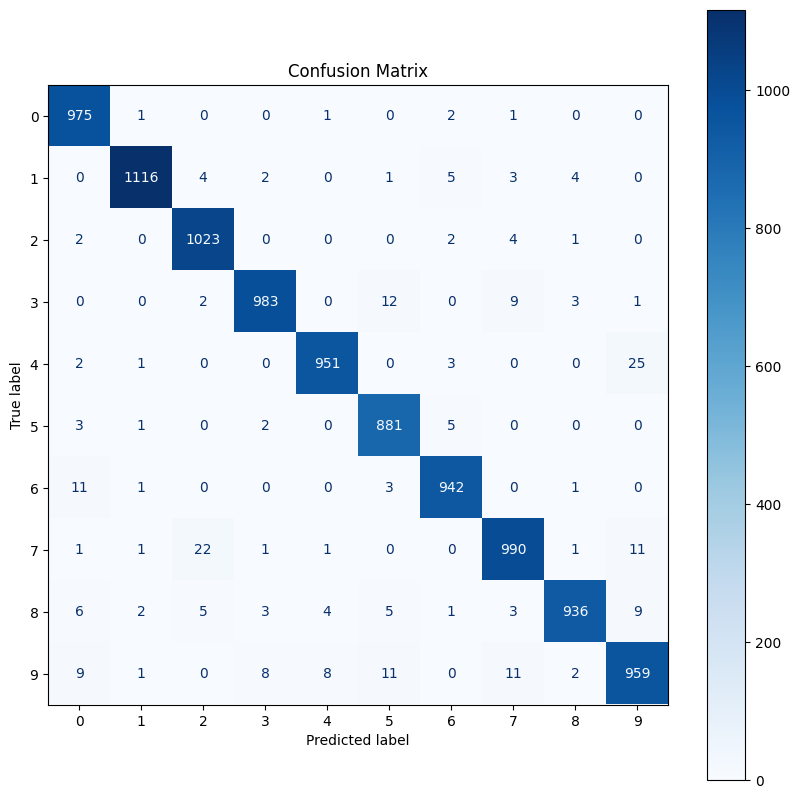

In [13]:
# confusion matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

C:\Users\Alex\AppData\Local\Temp\ipykernel_20200\3936228094.py:24: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Prediction: 2, Target: 2


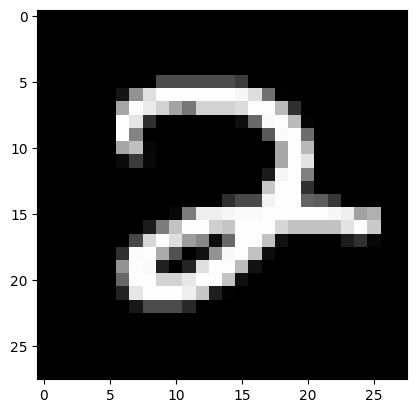

In [14]:
import matplotlib.pyplot as plt

model.eval()

data, target = test_data[764]

data = data.unsqueeze(0).to(device)

output = model(data)

prediction = output.argmax(dim=1, keepdim=True).item()

print(f'Prediction: {prediction}, Target: {target}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')
plt.show()

In [15]:
import torch
import onnx
from huggingface_hub import HfApi

# 1. Export
dummy_input = torch.randn(1, 1, 28, 28).to(device)
torch.onnx.export(
    model,
    dummy_input,
    "cnn_single.onnx",
    dynamo=True,
    input_names=["input"],
    output_names=["output"],
)

# 2. Merge into single file
model_proto = onnx.load("cnn_single.onnx")
onnx.save(model_proto, "cnn_single.onnx", save_as_external_data=False)

# 3. Upload to Hugging Face
api = HfApi()
api.upload_file(
    path_or_fileobj="cnn_single.onnx",
    path_in_repo="cnn_single.onnx",
    repo_id="booogiee/math_cnn",
    repo_type="model"
)

print("Done!")

C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\_export\non_strict_utils.py:1167: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return func(*args, **kwargs)


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


cnn_single.onnx: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98.3k/98.3k [00:00<00:00, 336kB/s]


Done!
